# ⚙️ 트랜스포머 알고리즘 구현 (Transformer from Scratch)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import seaborn as sns

## 1. Scaled Dot-Product Attention
트랜스포머의 가장 핵심 연산인 스케일드 닷 프로덕트 어텐션입니다.
$$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

Output Shape: torch.Size([1, 1, 4, 8])
Attention Weights Shape: torch.Size([1, 1, 4, 4])


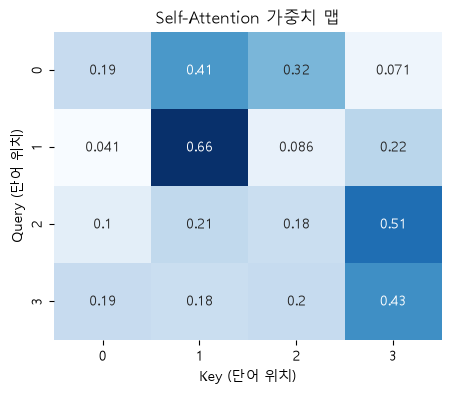

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K, V shape: (batch_size, num_heads, seq_len, d_k)
    d_k = Q.size(-1)
    
    # 1. Q * K^T (행렬 곱)
    # K.transpose(-2, -1)는 마지막 두 차원의 위치를 바꿈 (seq_len, d_k) -> (d_k, seq_len)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    
    # 2. Masking (옵션)
    if mask is not None:
        # 마스크 값이 0인 곳을 -무한대(-1e9)로 채워서 softmax 시 0이 되도록 함
        scores = scores.masked_fill(mask == 0, -1e9)
        
    # 3. Softmax
    attention_weights = F.softmax(scores, dim=-1)
    
    # 4. Multiply with V
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# 테스트를 위한 더미 데이터 (Batch=1, Heads=1, Seq=4, Dim=8)
torch.manual_seed(42)
Q = torch.randn(1, 1, 4, 8)
K = torch.randn(1, 1, 4, 8)
V = torch.randn(1, 1, 4, 8)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print("Output Shape:", output.shape)
print("Attention Weights Shape:", attn_weights.shape)

# 어텐션 스코어 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(attn_weights.squeeze().detach().numpy(), annot=True, cmap='Blues', cbar=False)
plt.title("Self-Attention 가중치 맵")
plt.xlabel("Key (단어 위치)")
plt.ylabel("Query (단어 위치)")
plt.show()

## 2. Multi-Head Attention
여러 개의 헤드로 입력을 나누어 병렬로 어텐션을 수행한 후 다시 합치는 모듈입니다.

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        self.d_k = d_model // num_heads
        
        # Q, K, V 변환을 위한 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # 최종 출력을 위한 선형 레이어
        self.W_o = nn.Linear(d_model, d_model)
        
    def split_heads(self, x, batch_size):
        # x shape: (batch_size, seq_len, d_model)
        # return shape: (batch_size, num_heads, seq_len, d_k)
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)
        
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        # 1. Linear projections
        Q = self.W_q(q)
        K = self.W_k(k)
        V = self.W_v(v)
        
        # 2. Split into multiple heads
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)
        
        # 3. Scaled Dot-Product Attention
        attn_output, _ = scaled_dot_product_attention(Q, K, V, mask)
        
        # 4. Concatenate heads
        # (batch_size, num_heads, seq_len, d_k) -> (batch_size, seq_len, num_heads, d_k) -> (batch_size, seq_len, d_model)
        concat_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # 5. Final linear projection
        output = self.W_o(concat_output)
        return output

mha = MultiHeadAttention(d_model=512, num_heads=8)
dummy_x = torch.randn(2, 10, 512) # Batch: 2, SeqLen: 10, Dim: 512
mha_out = mha(dummy_x, dummy_x, dummy_x)
print("Multi-Head Attention 출력 차원:", mha_out.shape)

Multi-Head Attention 출력 차원: torch.Size([2, 10, 512])


## 3. Positional Encoding
순서 정보를 $\sin$과 $\cos$ 함수를 통해 주입합니다.

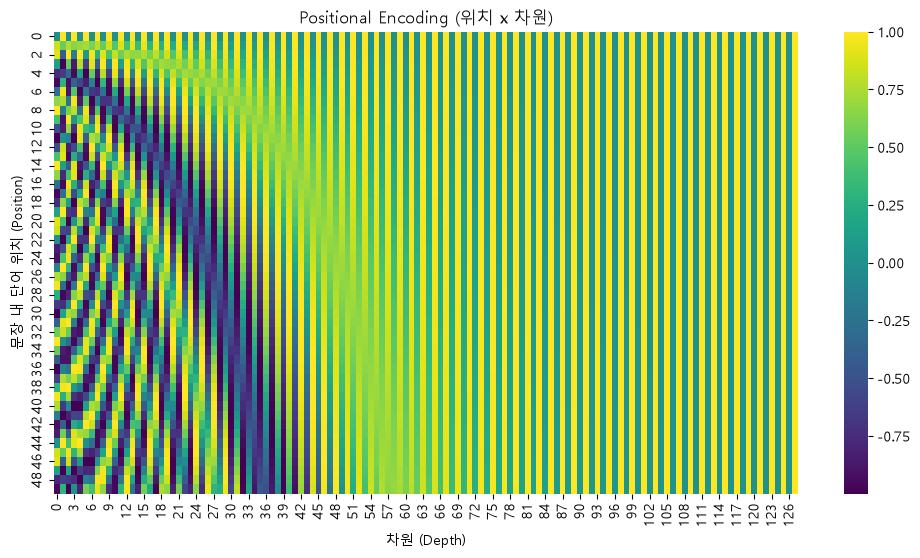

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # 0으로 채워진 (max_len, d_model) 행렬 생성
        pe = torch.zeros(max_len, d_model)
        
        # 위치 행렬: [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # 분모 값 계산: 10000^(2i/d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 짝수 인덱스에는 sin 적용
        pe[:, 0::2] = torch.sin(position * div_term)
        # 홀수 인덱스에는 cos 적용
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # pe shape: (1, max_len, d_model)
        pe = pe.unsqueeze(0)
        
        # buffer로 등록하여 모델 저장 시 함께 저장되도록 함 (학습되는 파라미터는 아님)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # 입력 시퀀스 길이만큼의 positional encoding을 더해줌
        x = x + self.pe[:, :x.size(1), :]
        return x

# 시각화 테스트
pe = PositionalEncoding(d_model=128, max_len=50)
pe_matrix = pe.pe.squeeze().numpy()

plt.figure(figsize=(12, 6))
sns.heatmap(pe_matrix, cmap='viridis')
plt.title("Positional Encoding (위치 x 차원)")
plt.xlabel("차원 (Depth)")
plt.ylabel("문장 내 단어 위치 (Position)")
plt.show()